In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(0)



In [30]:
def generator_01(T=300):
    """Deterministic 010101... generator."""
    seq = [t % 2 for t in range(T)]
    return np.array(seq)

def generator_001001(T=300):
    """Deterministic 001 repeat generator."""
    seq = []
    pattern = [0,0,1]
    for t in range(T):
        seq.append(pattern[t % 3])
    return np.array(seq)



In [31]:
# --- helpers ---
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- agent ---
class BettingAgentEA:
    def __init__(self, N=2, n_hypotheses=100, seed=0):
        self.rng = default_rng(seed)
        self.N = N
        self.H = n_hypotheses

        # Parameters: logits
        self.u = self.rng.normal(size=(self.H, N))       # emissions
        self.W = self.rng.normal(size=(self.H, N, N))    # transitions

        # Beliefs per hypothesis
        self.beliefs = np.ones((self.H, N)) / N

        # Fitness tracker
        self.fitness = np.zeros(self.H)

    def _decode_params(self):
        theta = sigmoid(self.u)              # emission probs
        T = softmax(self.W, axis=2)          # transition matrices
        return theta, T

    def predict(self):
        """Uniform average prediction over all hypotheses."""
        theta, _ = self._decode_params()
        preds = (self.beliefs * theta).sum(axis=1)  # per-hypothesis prob of '1'
        weights = self.fitness + 1e-6  # avoid div by zero
        weights /= weights.sum()
        agg_p = np.sum(weights * preds)                      
        return agg_p, preds

    def observe(self, y):
        """Update beliefs and fitness after seeing outcome y."""
        theta, T = self._decode_params()

        # emission likelihood per state
        e = theta**y * (1-theta)**(1-y)
        post = self.beliefs * e
        post /= post.sum(axis=1, keepdims=True)

        # transition forward
        self.beliefs = np.einsum('hi,hij->hj', post, T)

        # update fitness: log-likelihood of prediction
        preds = (self.beliefs * theta).sum(axis=1)
        accuracy = ( (preds > 0.5).astype(int) == y ).astype(float)
        self.fitness += accuracy


    def evolve(self, elite_frac=0.2, mut_std=0.1):
        elite_size = max(1, int(self.H * elite_frac))
        elite_idx = np.argsort(self.fitness)[-elite_size:]
        elites_u = self.u[elite_idx]
        elites_W = self.W[elite_idx]

        new_u, new_W = [], []
        for _ in range(self.H):
            idx = self.rng.integers(elite_size)
            child_u = elites_u[idx] + self.rng.normal(scale=mut_std, size=self.N)
            child_W = elites_W[idx] + self.rng.normal(scale=mut_std, size=(self.N,self.N))
            new_u.append(child_u)
            new_W.append(child_W)

        self.u = np.stack(new_u)
        self.W = np.stack(new_W)

        # reset beliefs and fitness
        self.beliefs = np.ones((self.H, self.N)) / self.N
       

In [35]:
def play_game(seq, agent, evolve_every=50):
    preds, actions, acc_curve = [], [], []
    correct = 0
    for t, y in enumerate(seq):
        agg_p, _ = agent.predict()
        preds.append(agg_p)
        action = int(agg_p > 0.5)
        actions.append(action)

        if action == y:
            correct += 1

        # cumulative accuracy up to now
        acc_curve.append(correct / (t+1))

        agent.observe(y)

        if (t+1) % evolve_every == 0 and t > 0:
            agent.evolve()

    return np.array(preds), np.array(actions), np.array(acc_curve)


# --- run ---
seq = generator_01(10000)
agent = BettingAgentEA(N=2, n_hypotheses=100, seed=0)
preds, actions, acc_curve = play_game(seq, agent, evolve_every=20)


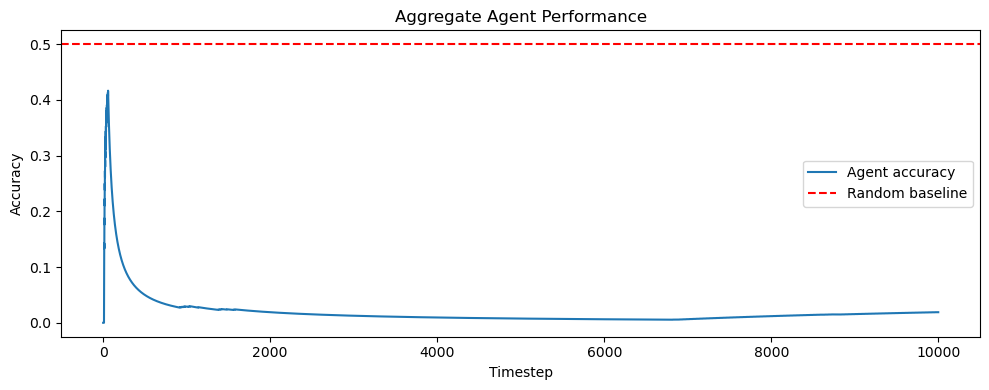

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(acc_curve, label="Agent accuracy")
plt.axhline(0.5, color='red', linestyle='--', label='Random baseline')
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Aggregate Agent Performance")
plt.legend()

plt.tight_layout()
plt.show()


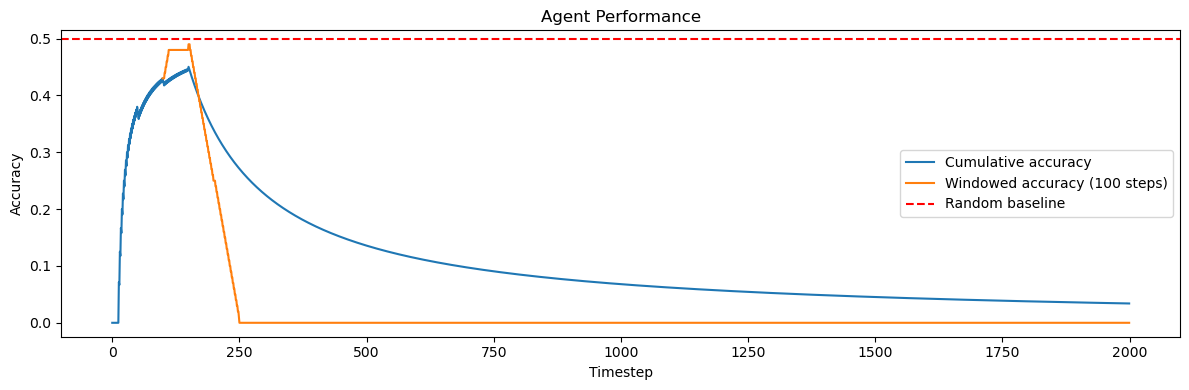

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

# --- generators ---
def generator_01(T=300):
    """Deterministic 010101... generator."""
    return np.array([t % 2 for t in range(T)])

def generator_001001(T=300):
    """Deterministic 001 repeat generator."""
    pattern = [0,0,1]
    return np.array([pattern[t % 3] for t in range(T)])

# --- helpers ---
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- agent ---
class BettingAgentEA:
    def __init__(self, N=2, n_hypotheses=100, seed=0, fitness_decay=0.9):
        self.rng = default_rng(seed)
        self.N = N
        self.H = n_hypotheses
        self.decay = fitness_decay

        # Parameters: logits
        self.u = self.rng.normal(size=(self.H, N))       # emissions
        self.W = self.rng.normal(size=(self.H, N, N))    # transitions

        # Beliefs per hypothesis
        self.beliefs = np.ones((self.H, N)) / N

        # Fitness tracker
        self.fitness = np.zeros(self.H)

    def _decode_params(self):
        theta = sigmoid(self.u)              # emission probs
        T = softmax(self.W, axis=2)          # transition matrices
        return theta, T

    def predict(self):
        """Prediction weighted by fitness."""
        theta, _ = self._decode_params()
        preds = (self.beliefs * theta).sum(axis=1)  # per-hypothesis prob of '1'
        weights = self.fitness + 1e-6
        weights /= weights.sum()
        agg_p = np.sum(weights * preds)
        return agg_p, preds

    def observe(self, y):
        """Update beliefs and fitness after seeing outcome y."""
        theta, T = self._decode_params()

        # emission likelihood per state
        e = theta**y * (1-theta)**(1-y)
        post = self.beliefs * e
        post /= post.sum(axis=1, keepdims=True)

        # transition forward
        self.beliefs = np.einsum('hi,hij->hj', post, T)

        # update fitness (with decay)
        preds = (self.beliefs * theta).sum(axis=1)
        accuracy = ((preds > 0.5).astype(int) == y).astype(float)
        self.fitness = self.decay * self.fitness + accuracy

    def evolve(self, elite_frac=0.2, mut_std=0.1, immigrant_frac=0.05):
        elite_size = max(1, int(self.H * elite_frac))
        immigrant_size = max(1, int(self.H * immigrant_frac))
        child_size = self.H - elite_size - immigrant_size

        elite_idx = np.argsort(self.fitness)[-elite_size:]
        elites_u = self.u[elite_idx]
        elites_W = self.W[elite_idx]

        new_u, new_W = [], []

        # 1. Keep elites
        new_u.extend(elites_u)
        new_W.extend(elites_W)

        # 2. Mutated children
        for _ in range(child_size):
            idx = self.rng.integers(elite_size)
            child_u = elites_u[idx] + self.rng.normal(scale=mut_std, size=self.N)
            child_W = elites_W[idx] + self.rng.normal(scale=mut_std, size=(self.N,self.N))
            new_u.append(child_u)
            new_W.append(child_W)

        # 3. Random immigrants
        for _ in range(immigrant_size):
            new_u.append(self.rng.normal(size=self.N))
            new_W.append(self.rng.normal(size=(self.N, self.N)))

        # stack into arrays
        self.u = np.stack(new_u)
        self.W = np.stack(new_W)

        # reset beliefs, keep fitness small noise (don’t zero out completely)
        self.beliefs = np.ones((self.H, self.N)) / self.N
        self.fitness = np.zeros(self.H)

# --- play loop ---
def play_game(seq, agent, evolve_every=50, window=100):
    preds, actions, cum_acc, win_acc = [], [], [], []
    correct = 0
    for t, y in enumerate(seq):
        agg_p, _ = agent.predict()
        action = int(agg_p > 0.5)
        preds.append(agg_p)
        actions.append(action)

        if action == y:
            correct += 1

        # cumulative accuracy
        cum_acc.append(correct / (t+1))

        # sliding window accuracy
        if t+1 >= window:
            win_acc.append(np.mean(np.array(actions[-window:]) == np.array(seq[t-window+1:t+1])))
        else:
            win_acc.append(np.nan)

        agent.observe(y)

        if (t+1) % evolve_every == 0 and t > 0:
            agent.evolve()

    return np.array(preds), np.array(actions), np.array(cum_acc), np.array(win_acc)

# --- run ---
seq = generator_01(2000)
agent = BettingAgentEA(N=2, n_hypotheses=100, seed=0, fitness_decay=0.9)
preds, actions, cum_acc, win_acc = play_game(seq, agent, evolve_every=50)

# --- plot ---
plt.figure(figsize=(12,4))
plt.plot(cum_acc, label="Cumulative accuracy")
plt.plot(win_acc, label="Windowed accuracy (100 steps)")
plt.axhline(0.5, color='red', linestyle='--', label="Random baseline")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Agent Performance")
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
# count values in actions
unique, counts = np.unique(actions, return_counts=True)
print("Action counts:", dict(zip(unique, counts)))



Action counts: {0: 857, 1: 1143}


In [42]:
seq

array([0, 1, 0, ..., 1, 0, 1])

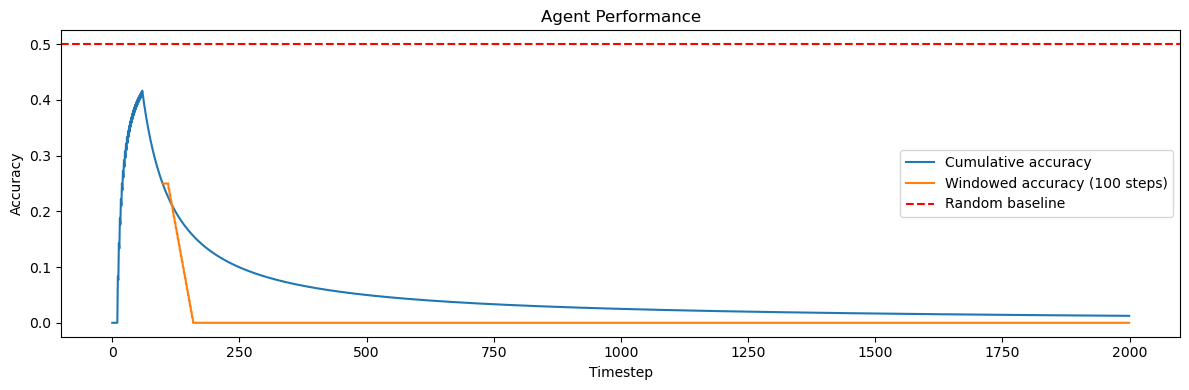

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(0)

# --- generators ---
def generator_01(T=300):
    """Deterministic 010101... generator."""
    return np.array([t % 2 for t in range(T)])

def generator_001001(T=300):
    """Deterministic 001 repeat generator."""
    pattern = [0, 0, 1]
    return np.array([pattern[t % 3] for t in range(T)])


# --- helpers ---
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# --- agent ---
class BettingAgentEA:
    def __init__(self, N=2, n_hypotheses=100, seed=0):
        self.rng = default_rng(seed)
        self.N = N
        self.H = n_hypotheses

        # Parameters: logits
        self.u = self.rng.normal(size=(self.H, N))       # emissions
        self.W = self.rng.normal(size=(self.H, N, N))    # transitions

        # Beliefs per hypothesis
        self.beliefs = np.ones((self.H, N)) / N

        # Fitness tracker
        self.fitness = np.zeros(self.H)

    def _decode_params(self):
        theta = sigmoid(self.u)              # emission probs
        T = softmax(self.W, axis=2)          # transition matrices
        return theta, T

    def predict(self):
        """Weighted average prediction over all hypotheses."""
        theta, _ = self._decode_params()
        preds = (self.beliefs * theta).sum(axis=1)  # per-hypothesis prob of '1'
        weights = self.fitness + 1e-6  # avoid div by zero
        weights /= weights.sum()
        agg_p = np.sum(weights * preds)
        return agg_p, preds

    def observe(self, y):
        """Update beliefs and fitness after seeing outcome y."""
        theta, T = self._decode_params()

        # emission likelihood per state
        e = theta**y * (1-theta)**(1-y)
        post = self.beliefs * e
        post /= post.sum(axis=1, keepdims=True)

        # transition forward
        self.beliefs = np.einsum('hi,hij->hj', post, T)

        # update fitness: 1 if correct prediction
        preds = (self.beliefs * theta).sum(axis=1)
        accuracy = ((preds > 0.5).astype(int) == y).astype(float)
        # exponential moving average for stability
        self.fitness = 0.95 * self.fitness + 0.05 * accuracy

    def evolve(self, elite_frac=0.2, mut_std=0.1, immigrant_frac=0.1):
        elite_size = max(1, int(self.H * elite_frac))
        imm_count = int(self.H * immigrant_frac)

        elite_idx = np.argsort(self.fitness)[-elite_size:]
        elites_u = self.u[elite_idx]
        elites_W = self.W[elite_idx]
        elites_beliefs = self.beliefs[elite_idx]
        elites_fitness = self.fitness[elite_idx]

        new_u, new_W, new_beliefs, new_fitness = [], [], [], []

        # keep elites
        new_u.extend(elites_u)
        new_W.extend(elites_W)
        new_beliefs.extend(elites_beliefs)
        new_fitness.extend(elites_fitness)

        # immigrants (fresh random)
        for _ in range(imm_count):
            new_u.append(self.rng.normal(size=self.N))
            new_W.append(self.rng.normal(size=(self.N, self.N)))
            new_beliefs.append(np.ones(self.N) / self.N)
            new_fitness.append(0.0)

        # rest: mutated children
        while len(new_u) < self.H:
            idx = self.rng.integers(elite_size)
            child_u = elites_u[idx] + self.rng.normal(scale=mut_std, size=self.N)
            child_W = elites_W[idx] + self.rng.normal(scale=mut_std, size=(self.N, self.N))
            new_u.append(child_u)
            new_W.append(child_W)
            new_beliefs.append(np.ones(self.N) / self.N)  # reset for children
            new_fitness.append(0.0)  # children start fresh

        self.u = np.stack(new_u)
        self.W = np.stack(new_W)
        self.beliefs = np.stack(new_beliefs)
        self.fitness = np.array(new_fitness)


# --- play loop ---
def play_game(seq, agent, evolve_every=50, window=100):
    preds, actions = [], []
    correct = 0
    cum_acc, win_acc = [], []

    for t, y in enumerate(seq):
        agg_p, _ = agent.predict()
        action = int(agg_p > 0.5)

        preds.append(agg_p)
        actions.append(action)

        if action == y:
            correct += 1

        # cumulative accuracy
        cum_acc.append(correct / (t+1))

        # windowed accuracy
        if t >= window:
            win_acc.append(np.mean(np.array(actions[-window:]) == np.array(seq[t-window+1:t+1])))
        else:
            win_acc.append(np.nan)

        agent.observe(y)

        if (t+1) % evolve_every == 0:
            agent.evolve()

    return np.array(preds), np.array(actions), np.array(cum_acc), np.array(win_acc)


# --- run ---
seq = generator_01(2000)
agent = BettingAgentEA(N=2, n_hypotheses=100, seed=0)
preds, actions, cum_acc, win_acc = play_game(seq, agent, evolve_every=20, window=100)

# --- plot ---
plt.figure(figsize=(12,4))
plt.plot(cum_acc, label="Cumulative accuracy")
plt.plot(win_acc, label="Windowed accuracy (100 steps)")
plt.axhline(0.5, color='red', linestyle='--', label='Random baseline')
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Agent Performance")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
import numpy as np

class SimpleHMM:
    def __init__(self, N=2):
        self.N = N
        self.transition_counts = np.ones((N, N))   # Dirichlet prior
        self.emission_counts = np.ones((N, 2))     # assume binary emissions
        self.state = 0

    def predict(self):
        """Predict probability of 1 given current state."""
        # emission probability from current state
        probs = self.emission_counts[self.state] / self.emission_counts[self.state].sum()
        return probs[1]   # prob of emitting "1"

    def observe(self, y):
        """Update counts after seeing y."""
        # update emission
        self.emission_counts[self.state, y] += 1
        
        # pick next state by maximizing likelihood (greedy decode)
        next_state = (self.state + 1) % self.N
        self.transition_counts[self.state, next_state] += 1
        self.state = next_state


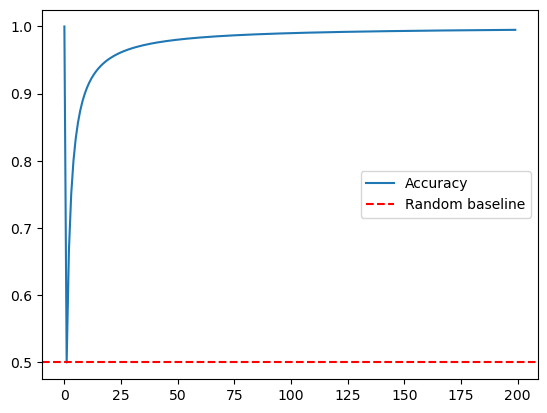

In [54]:
def play_game(seq, agent):
    preds, actions, acc_curve = [], [], []
    correct = 0
    for t, y in enumerate(seq):
        p = agent.predict()
        preds.append(p)
        action = int(p > 0.5)
        actions.append(action)

        if action == y:
            correct += 1
        acc_curve.append(correct / (t+1))

        agent.observe(y)

    return np.array(preds), np.array(actions), np.array(acc_curve)


# Run on alternating 0101 sequence
seq = [t % 2 for t in range(200)]
agent = SimpleHMM(N=2)
preds, actions, acc_curve = play_game(seq, agent)

import matplotlib.pyplot as plt
plt.plot(acc_curve, label="Accuracy")
plt.axhline(0.5, color='r', linestyle='--', label="Random baseline")
plt.legend()
plt.show()


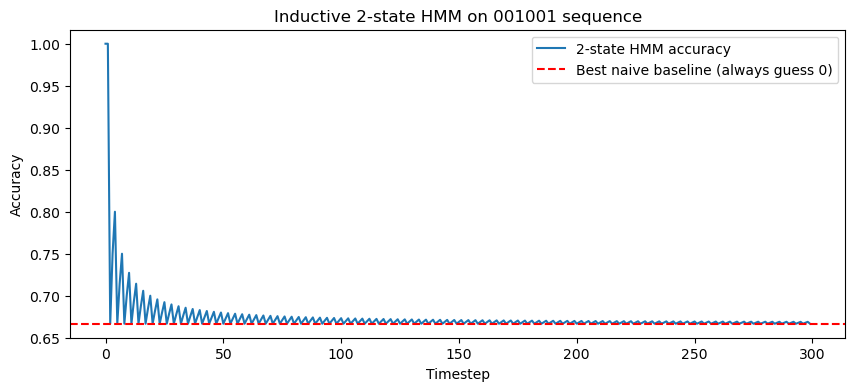

In [55]:
seq = generator_001001(300)
agent = SimpleHMM(N=2)
preds, actions, acc_curve = play_game(seq, agent)

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(acc_curve, label="2-state HMM accuracy")
plt.axhline(1/3*2, color='r', linestyle='--', label="Best naive baseline (always guess 0)")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Inductive 2-state HMM on 001001 sequence")
plt.legend()
plt.show()

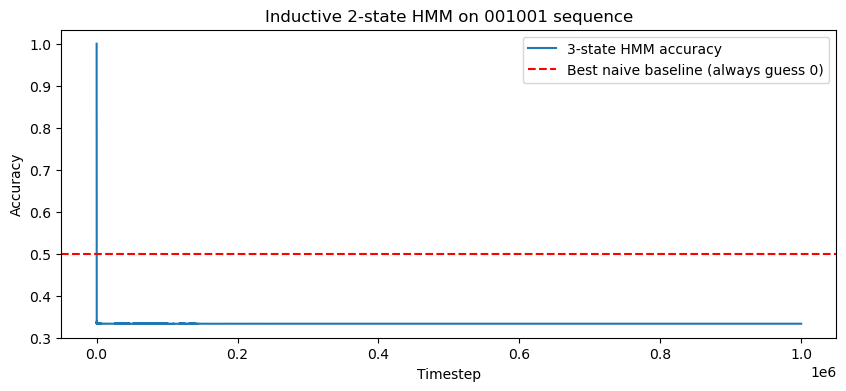

In [ ]:
seq = generator_01(10000)
agent = SimpleHMM(N=3)
preds, actions, acc_curve = play_game(seq, agent)

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(acc_curve, label="3-state HMM accuracy")
plt.axhline(0.5, color='r', linestyle='--', label="Best naive baseline (always guess 0)")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Inductive 2-state HMM on 001001 sequence")
plt.legend()
plt.show()

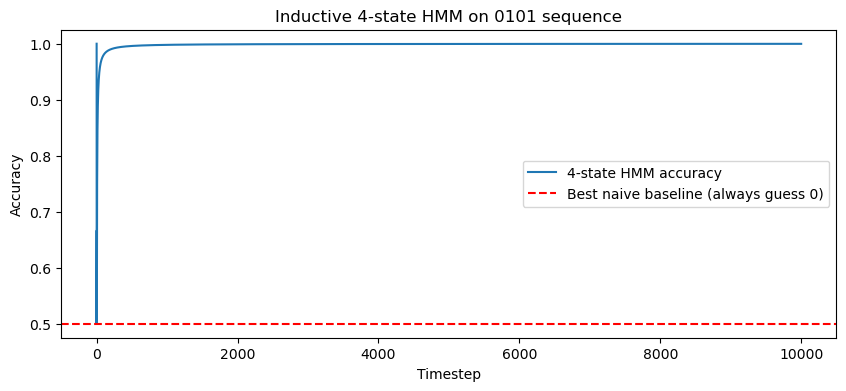

In [70]:
seq = generator_01(10000)
agent = SimpleHMM(N=4)
preds, actions, acc_curve = play_game(seq, agent)

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(acc_curve, label="4-state HMM accuracy")
plt.axhline(0.5, color='r', linestyle='--', label="Best naive baseline (always guess 0)")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Inductive 4-state HMM on 0101 sequence")
plt.legend()
plt.show()

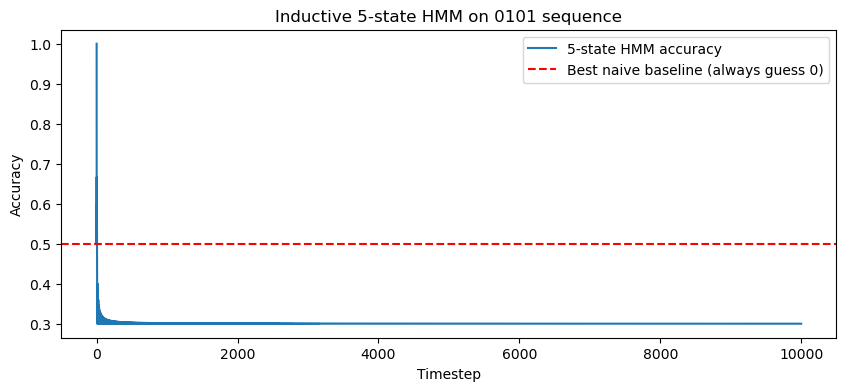

In [71]:
seq = generator_01(10000)
agent = SimpleHMM(N=5)
preds, actions, acc_curve = play_game(seq, agent)

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(acc_curve, label="5-state HMM accuracy")
plt.axhline(0.5, color='r', linestyle='--', label="Best naive baseline (always guess 0)")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Inductive 5-state HMM on 0101 sequence")
plt.legend()
plt.show()

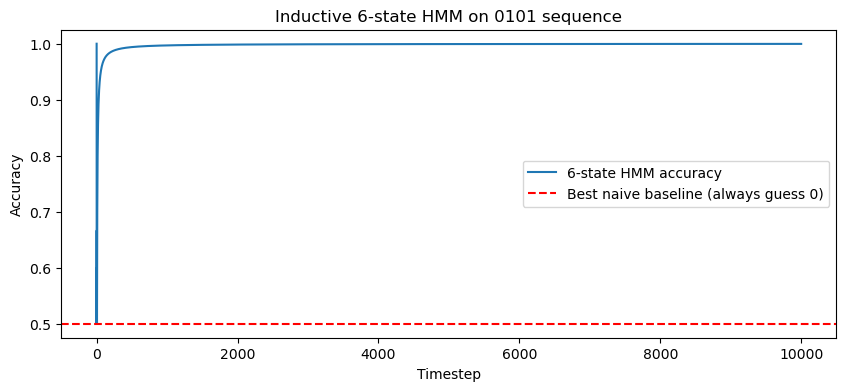

In [73]:
seq = generator_01(10000)
agent = SimpleHMM(N=6)
preds, actions, acc_curve = play_game(seq, agent)

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(acc_curve, label="6-state HMM accuracy")
plt.axhline(0.5, color='r', linestyle='--', label="Best naive baseline (always guess 0)")
plt.xlabel("Timestep")
plt.ylabel("Accuracy")
plt.title("Inductive 6-state HMM on 0101 sequence")
plt.legend()
plt.show()